# **Projet de Marketing Quantitatif**

Direcrted by:


*   **Ablaye SOW**
*   **Marie-Danielle DAKON**
*   **Constantin DOBRESCO**






**Contexte du projet:**

Nous analysons les ventes de billets pour différents événements. Nous avons constaté qu’un certain nombre de clients n’achètent plus nos produits. L’objectif est donc d’améliorer la prochaine campagne de relance afin de retenir ces clients.

Pour cela, nous utilisons un extrait de la base de ventes (**data_projet.csv**)contenant les données clients pour une catégorie spécifique d’événements. Les données ont été préalablement nettoyées afin de traiter les valeurs manquantes et aberrantes.

Nous allons identifier les clients à risque de départ sur une première période, puis observer sur une seconde période lesquels ont effectué un nouvel achat.

À partir de ces informations, nous entraînerons un modèle de classification afin de construire un score client et optimiser la rentabilité de la campagne de relance.

**Importation des bibliothèques nécessaires**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import datetime

/home/layedev/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
# Modèles et évaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE


# **Partie I - Création de la base de données**

## 1. Chargement des données

In [ ]:
df = pd.read_csv('data_projet.csv', parse_dates=['date_creation', 'date_utilisation', 'DDN'])
df = df.drop(columns = 'Unnamed: 0', axis =1)
df.head()

,id_billet,commande,date_creation,id_client,prix,date_utilisation,source,begin_on,ville,Source,...,DDN,sub,sub_notif,sub_newsletter,age_event,anticipation,begin_on_year,begin_on_month,JDS,utilise
0,0,0,2024-05-20 23:38:17,3753,7.99,2024-06-08 01:09:18,CRM240608,2024-06-07,Lille,CRM240608,...,2005-05-19,0.0,0.0,0.0,19,17,2024,6,0,1
1,1,1,2024-05-21 01:11:17,1323,7.99,2024-06-08 01:55:08,CRM240608,2024-06-07,Lille,CRM240608,...,2003-01-01,0.0,0.0,0.0,21,16,2024,6,1,1
2,2,2,2024-05-21 01:27:30,3743,7.99,2024-06-08 00:11:39,CRM240608,2024-06-07,Lille,CRM240608,...,2003-05-24,0.0,0.0,0.0,21,16,2024,6,1,1
3,3,3,2024-05-21 01:29:29,1432,7.99,2024-06-08 00:11:47,CRM240608,2024-06-07,Lille,CRM240608,...,2005-01-01,0.0,0.0,0.0,19,16,2024,6,1,1
4,4,4,2024-05-21 01:35:59,4657,7.99,2024-06-08 00:30:54,CRM240608,2024-06-07,Lille,CRM240608,...,2001-01-01,0.0,0.0,0.0,23,16,2024,6,1,1


In [ ]:

## Vérification des valeurs manquantes
df.isna().sum()

id_billet              0
commande               0
date_creation          0
id_client              0
prix                   0
date_utilisation    1322
source                 0
begin_on               0
ville                  0
Source                 0
Lieu                   0
Type_Lieu              0
sexe                   0
DDN                    0
sub                    0
sub_notif              0
sub_newsletter         0
age_event              0
anticipation           0
begin_on_year          0
begin_on_month         0
JDS                    0
utilise                0
dtype: int64

##### Traitement des valeurs manquantes

In [ ]:
## Ici on remplace les valeurs manquantes de la colonne 'date_utilisation' par la médiane des dates d'utilisation pour chaque source.
# Cela permet de conserver une estimation raisonnable de la date d'utilisation pour les enregistrements où elle est manquante,
# tout en tenant compte des différences potentielles entre les sources.
df['date_utilisation'] = df['date_utilisation'].fillna(
    df.groupby('source')['date_utilisation']
           .transform(lambda x: x.dropna().median())
)

In [ ]:
## Vérification des types de données et des valeurs uniques
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8688 entries, 0 to 8687
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_billet         8688 non-null   int64         
 1   commande          8688 non-null   int64         
 2   date_creation     8688 non-null   datetime64[ns]
 3   id_client         8688 non-null   int64         
 4   prix              8688 non-null   float64       
 5   date_utilisation  8688 non-null   datetime64[ns]
 6   source            8688 non-null   object        
 7   begin_on          8688 non-null   object        
 8   ville             8688 non-null   object        
 9   Source            8688 non-null   object        
 10  Lieu              8688 non-null   object        
 11  Type_Lieu         8688 non-null   object        
 12  sexe              8688 non-null   object        
 13  DDN               8688 non-null   datetime64[ns]
 14  sub               8688 n

## 2. Construction des deux tables

In [ ]:
## On défnit une date seuil pour séparer les transactions "anciennes" des transactions "complètes".
seuil = pd.to_datetime('2025-01-01')

# Table "ancienne" : transactions avant la date seuil
df_ancienne = df[df['date_creation'] < seuil].copy()

# Table "complète" : toutes les transactions
df_complete = df.copy()

## 3. Calcul du score RFM pour chaque client dans chaque table


##### 3.1 Définition du dictionnaire de scores RFM

In [ ]:
# Dates de référence pour le calcul de la récence
date_ref_ancienne = seuil - pd.Timedelta(days=1)   # veille du seuil
date_ref_complete = df_complete['date_creation'].max()  # dernière transaction

# Dictionnaire de classification RFM fourni
# RFM
# TBC : Très bon client
# CF : Client Fidèle
# CR : Client Récens
# CPP : Client à ne pas perdre
# CEV :  Client en veille
# CP : Client Perdus
# NA : Non caractérisé

rfm_dict = {
    # TBC
    '555': 'TBC',

    # CF
    '554': 'CF', '545': 'CF', '455': 'CF',
    '544': 'CF', '445': 'CF', '454': 'CF', '444': 'CF',

    # CR
    '511': 'CR', '512': 'CR', '513': 'CR', '514': 'CR', '515': 'CR',
    '521': 'CR', '522': 'CR', '523': 'CR', '524': 'CR', '525': 'CR',
    '531': 'CR', '532': 'CR', '534': 'CR', '535': 'CR',

    '411': 'CR', '412': 'CR', '413': 'CR', '414': 'CR', '415': 'CR',
    '421': 'CR', '422': 'CR', '423': 'CR', '424': 'CR', '425': 'CR',
    '431': 'CR', '432': 'CR', '433': 'CR', '434': 'CR', '435': 'CR',

    # CPP
    '355': 'CPP', '345': 'CPP', '354': 'CPP', '344': 'CPP',

    # CEV
    '333': 'CEV', '332': 'CEV', '331': 'CEV',
    '323': 'CEV', '322': 'CEV', '321': 'CEV',
    '313': 'CEV', '312': 'CEV', '311': 'CEV',

    # CP
    '111': 'CP', '112': 'CP', '113': 'CP',
    '121': 'CP', '122': 'CP', '123': 'CP',
    '131': 'CP', '132': 'CP', '133': 'CP',
    '211': 'CP', '212': 'CP', '213': 'CP',
    '221': 'CP', '222': 'CP', '223': 'CP',
    '231': 'CP', '232': 'CP', '233': 'CP'
}
ordre_RFM = ['TBC', 'CF', 'CR', 'CPP', 'CEV', 'CP', 'NA']

##### 3.2 Calcul du score RFM pour chaque client dans la table "ancienne"

In [ ]:
# --- Calcul pour la table ancienne ---
# Agrégation par client
clients_ancien = df_ancienne.groupby('id_client').agg(
    DDN_max=('DDN', 'max'),
    sexe_mode=('sexe', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Inconnu'),
    prix_total=('prix', 'sum'),
    nb_billets=('id_billet', 'nunique'),
    nb_commandes=('commande', 'nunique'),
    nb_sources=('source', 'nunique'),
    anticipation_moy=('anticipation', 'mean'),
    date_creation_min=('date_creation', 'min'),
    date_creation_max=('date_creation', 'max')
).reset_index()

# Calcul de la récence par rapport à la date de référence ancienne
clients_ancien['recence'] = (date_ref_ancienne - clients_ancien['date_creation_max']).dt.days

# Calcul des scores R, F, M selon la méthode fournie
clients_ancien['R_score'] = pd.qcut(
    clients_ancien['recence'],
    q=5,
    labels=range(5, 0, -1)  # 5 = plus récent, 1 = moins récent
).astype(str)

# Pour F, on utilise rank(method='first') pour gérer les ex-aequo
clients_ancien['F_score'] = pd.qcut(
    clients_ancien['nb_commandes'].rank(method='first'),
    q=5,
    labels=range(1, 6)
).astype(str)

clients_ancien['M_score'] = pd.qcut(
    clients_ancien['prix_total'],
    q=5,
    labels=range(1, 6)
).astype(str)

# Création du code RFM concaténé
clients_ancien['RFM_code'] = clients_ancien['R_score'] + clients_ancien['F_score'] + clients_ancien['M_score']

In [ ]:
# Application de la classification
clients_ancien['RFM_cat'] = clients_ancien['RFM_code'].map(rfm_dict).fillna('NA')
clients_ancien['RFM_cat'] = pd.Categorical(clients_ancien['RFM_cat'], categories=ordre_RFM, ordered=True)
clients_ancien.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat
0,1,2003-05-24,M,17.99,1,1,1,0.0,2024-10-17 08:06:30,2024-10-17 08:06:30,74,5,1,3,513,CR
1,2,2003-05-25,M,10.00,1,1,1,-1.0,2023-05-05 15:45:00,2023-05-05 15:45:00,605,1,1,1,111,CP
2,7,2001-01-06,F,10.99,1,1,1,17.0,2023-09-25 21:05:00,2023-09-25 21:05:00,462,2,1,1,211,CP
3,8,2003-05-24,M,10.99,1,1,1,8.0,2024-02-07 10:12:51,2024-02-07 10:12:51,327,3,1,1,311,CEV
4,48,2003-05-24,F,13.35,1,1,1,-1.0,2023-09-15 21:41:03,2023-09-15 21:41:03,472,2,1,2,212,CP


##### 3.3 Calcul du score RFM pour chaque client dans la table "complète"

In [ ]:
# --- Calcul pour la table complète ---
clients_complet = df_complete.groupby('id_client').agg(
    DDN_max=('DDN', 'max'),
    sexe_mode=('sexe', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Inconnu'),
    prix_total=('prix', 'sum'),
    nb_billets=('id_billet', 'nunique'),
    nb_commandes=('commande', 'nunique'),
    nb_sources=('source', 'nunique'),
    anticipation_moy=('anticipation', 'mean'),
    date_creation_min=('date_creation', 'min'),
    date_creation_max=('date_creation', 'max')
).reset_index()

clients_complet['recence'] = (date_ref_complete - clients_complet['date_creation_max']).dt.days

clients_complet['R_score'] = pd.qcut(
    clients_complet['recence'],
    q=5,
    labels=range(5, 0, -1)
).astype(str)

clients_complet['F_score'] = pd.qcut(
    clients_complet['nb_commandes'].rank(method='first'),
    q=5,
    labels=range(1, 6)
).astype(str)

clients_complet['M_score'] = pd.qcut(
    clients_complet['prix_total'],
    q=5,
    labels=range(1, 6)
).astype(str)


In [ ]:
clients_complet['RFM_code'] = clients_complet['R_score'] + clients_complet['F_score'] + clients_complet['M_score']
clients_complet['RFM_cat'] = clients_complet['RFM_code'].map(rfm_dict).fillna('NA')
clients_complet['RFM_cat'] = pd.Categorical(clients_complet['RFM_cat'], categories=ordre_RFM, ordered=True)
clients_complet.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat
0,1,2003-05-24,M,17.99,1,1,1,0.0,2024-10-17 08:06:30,2024-10-17 08:06:30,414,2,1,3,213,CP
1,2,2003-05-25,M,10.00,1,1,1,-1.0,2023-05-05 15:45:00,2023-05-05 15:45:00,945,1,1,1,111,CP
2,4,2003-02-08,M,12.99,1,1,1,-2.0,2025-07-14 01:56:29,2025-07-14 01:56:29,145,4,1,1,411,CR
3,5,2005-07-15,F,15.99,1,1,1,0.0,2025-06-05 00:06:34,2025-06-05 00:06:34,184,4,1,3,413,CR
4,7,2001-01-06,F,10.99,1,1,1,17.0,2023-09-25 21:05:00,2023-09-25 21:05:00,802,1,1,1,111,CP


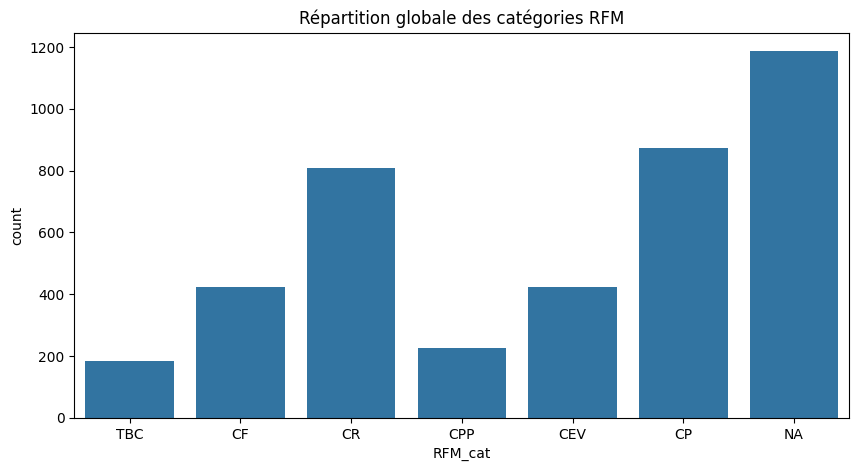

In [ ]:
# On fait un graphique pour visualiser la répartition des catégories RFM dans la table complète
import matplotlib_inline
plt.figure(figsize=(10,5))
sns.countplot(data=clients_complet, x='RFM_cat', order=ordre_RFM)
plt.title('Répartition globale des catégories RFM')
plt.show()

Nous constatons que les clients non catégorisés par le score RFM dans la table "ancienne" sont majoritaires dans la table "complète". Cela suggère que ces clients ont effectué des achats récents, ce qui les rend plus susceptibles d'être actifs dans la table "complète".

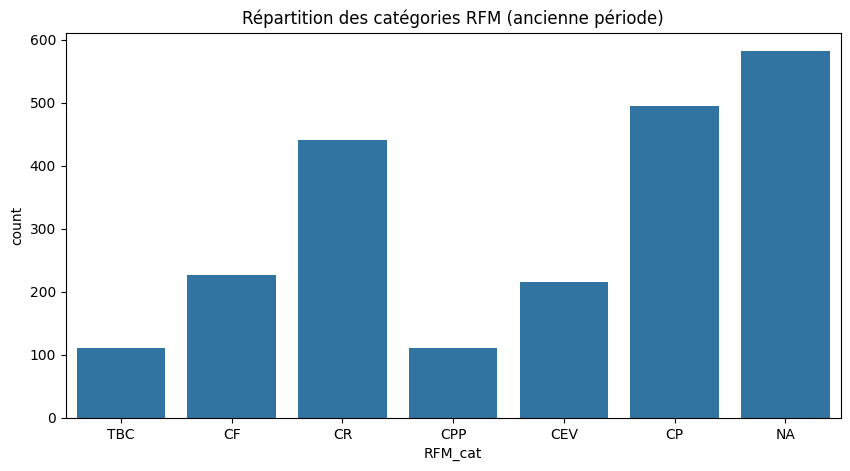

In [ ]:
# Graphique pour visualiser la répartition des catégories RFM dans la table ancienne
import matplotlib_inline
plt.figure(figsize=(10,5))
sns.countplot(data=clients_ancien, x='RFM_cat', order=ordre_RFM)
plt.title('Répartition des catégories RFM (ancienne période)')
plt.show()

Pareillement, nous remarquons le meme phénomène pour les clients non catégorisés que dans la table complète.

## 4-Identifier les clients "à ne pas perdre" (CPP) dans la table ancienne


In [ ]:
## les clients "à ne pas perdre" sont ceux de la catégorie CPP (Client à ne pas perdre).
# Nous allons les identifier et calculer leur proportion par rapport à l'ensemble des clients de la période ancienne.
clients_a_ne_pas_perdre = clients_ancien[clients_ancien['RFM_cat'] == 'CPP'].copy()
print(f"\nNombre de clients 'à ne pas perdre' (catégorie CPP) : {len(clients_a_ne_pas_perdre)}")
print(f"Soit {len(clients_a_ne_pas_perdre)/len(clients_ancien)*100:.2f}% des clients de la période ancienne.")



Nombre de clients 'à ne pas perdre' (catégorie CPP) : 111
Soit 5.09% des clients de la période ancienne.


In [ ]:
clients_a_ne_pas_perdre.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat
42,217,2005-01-01,F,37.97,3,2,2,3.333333,2024-02-14 19:54:02,2024-05-29 16:06:06,215,3,4,5,345,CPP
69,298,2001-01-01,F,36.35,3,2,2,3.333333,2023-09-14 23:25:31,2024-04-06 23:27:16,268,3,4,5,345,CPP
85,340,2003-01-01,F,26.28,2,2,2,2.000000,2023-09-10 12:58:32,2024-02-15 16:04:56,319,3,4,4,344,CPP
137,481,2000-01-01,F,41.38,3,3,3,0.333333,2023-09-15 22:29:03,2024-04-08 12:18:29,266,3,5,5,355,CPP
138,485,1999-03-12,F,44.96,3,2,2,-1.000000,2023-10-13 20:36:00,2024-06-07 19:34:18,206,3,4,5,345,CPP


## 5-Identification des clients ayant effectué un achat après août 2025


In [ ]:
## On récupère ayant acheté après le seuil pour voir combien de clients "à ne pas perdre" sont redevenus actifs dans la table complète.
achats_apres = df_complete[df_complete['date_creation'] >= seuil]
## On récupère les clients uniques ayant acheté après le seuil pour les comparer avec les clients "à ne pas perdre".
clients_ayant_achete_apres = achats_apres['id_client'].unique()
## On fait une jointure pour identifier les clients "à ne pas perdre" qui ont effectué des achats après le seuil, ce qui les rend "redevenus actifs" dans la table complète.
clients_re_actifs = pd.merge(left=clients_a_ne_pas_perdre,
                             right=pd.DataFrame(clients_ayant_achete_apres, columns=['id_client']),
                             on='id_client', how='inner')

clients_re_actifs.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat
0,217,2005-01-01,F,37.97,3,2,2,3.333333,2024-02-14 19:54:02,2024-05-29 16:06:06,215,3,4,5,345,CPP
1,537,2004-06-24,F,40.97,3,2,2,0.666667,2024-02-15 19:29:18,2024-04-10 21:14:35,264,3,4,5,345,CPP
2,857,1999-01-01,M,75.23,7,7,7,8.000000,2023-04-26 14:51:00,2024-03-30 06:22:49,275,3,5,5,355,CPP
3,899,2002-01-01,M,23.99,2,2,2,-0.500000,2023-05-05 18:27:00,2024-02-15 02:19:18,319,3,4,4,344,CPP
4,1249,2004-10-30,F,25.98,2,2,2,1.500000,2024-04-07 16:47:24,2024-06-07 21:40:00,206,3,4,4,344,CPP


### 6-Construction de la table d’apprentissage et création de la variable cible

In [ ]:
df_apprentissage = clients_a_ne_pas_perdre.copy()
# On crée une variable binaire indiquant si le client "à ne pas perdre" est redevenu actif (1) ou pas (0).
df_apprentissage['re_achat'] = df_apprentissage['id_client'].isin(clients_ayant_achete_apres).astype(int)

# Ajout d'autres variables (exemple : taux d'utilisation) qui pourrait être pertinent pour prédire le réachat.
taux_util = df_ancienne.groupby('id_client')['utilise'].mean().reset_index(name='taux_utilisation')
df_apprentissage = df_apprentissage.merge(taux_util, on='id_client', how='left')

df_apprentissage.head()

,id_client,DDN_max,sexe_mode,prix_total,nb_billets,nb_commandes,nb_sources,anticipation_moy,date_creation_min,date_creation_max,recence,R_score,F_score,M_score,RFM_code,RFM_cat,re_achat,taux_utilisation
0,217,2005-01-01,F,37.97,3,2,2,3.333333,2024-02-14 19:54:02,2024-05-29 16:06:06,215,3,4,5,345,CPP,1,0.666667
1,298,2001-01-01,F,36.35,3,2,2,3.333333,2023-09-14 23:25:31,2024-04-06 23:27:16,268,3,4,5,345,CPP,0,0.666667
2,340,2003-01-01,F,26.28,2,2,2,2.000000,2023-09-10 12:58:32,2024-02-15 16:04:56,319,3,4,4,344,CPP,0,1.000000
3,481,2000-01-01,F,41.38,3,3,3,0.333333,2023-09-15 22:29:03,2024-04-08 12:18:29,266,3,5,5,355,CPP,0,1.000000
4,485,1999-03-12,F,44.96,3,2,2,-1.000000,2023-10-13 20:36:00,2024-06-07 19:34:18,206,3,4,5,345,CPP,0,1.000000


In [ ]:
df_apprentissage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_client          111 non-null    int64         
 1   DDN_max            111 non-null    datetime64[ns]
 2   sexe_mode          111 non-null    object        
 3   prix_total         111 non-null    float64       
 4   nb_billets         111 non-null    int64         
 5   nb_commandes       111 non-null    int64         
 6   nb_sources         111 non-null    int64         
 7   anticipation_moy   111 non-null    float64       
 8   date_creation_min  111 non-null    datetime64[ns]
 9   date_creation_max  111 non-null    datetime64[ns]
 10  recence            111 non-null    int64         
 11  R_score            111 non-null    object        
 12  F_score            111 non-null    object        
 13  M_score            111 non-null    object        
 14  RFM_code  

# **Partie II - Traitement des données**

## 1-Analyse univariée des variables

In [ ]:
## On définit les variables d'intérêt pour l'apprentissage, en s'assurant qu'elles sont présentes dans le DataFrame
## Cette liste de variables serviront de variables explicatives pour prédire la variable cible 're_achat'
features = [f for f in df_apprentissage.columns if f not in ['id_client', 're_achat', 'RFM_cat', 'RFM_code']]
features_numeriques =  df_apprentissage[features].select_dtypes(include=[np.number]).columns.tolist()


Variables numériques :  ['DDN_max', 'sexe_mode', 'prix_total', 'nb_billets', 'nb_commandes', 'nb_sources', 'anticipation_moy', 'date_creation_min', 'date_creation_max', 'recence', 'R_score', 'F_score', 'M_score', 'taux_utilisation']


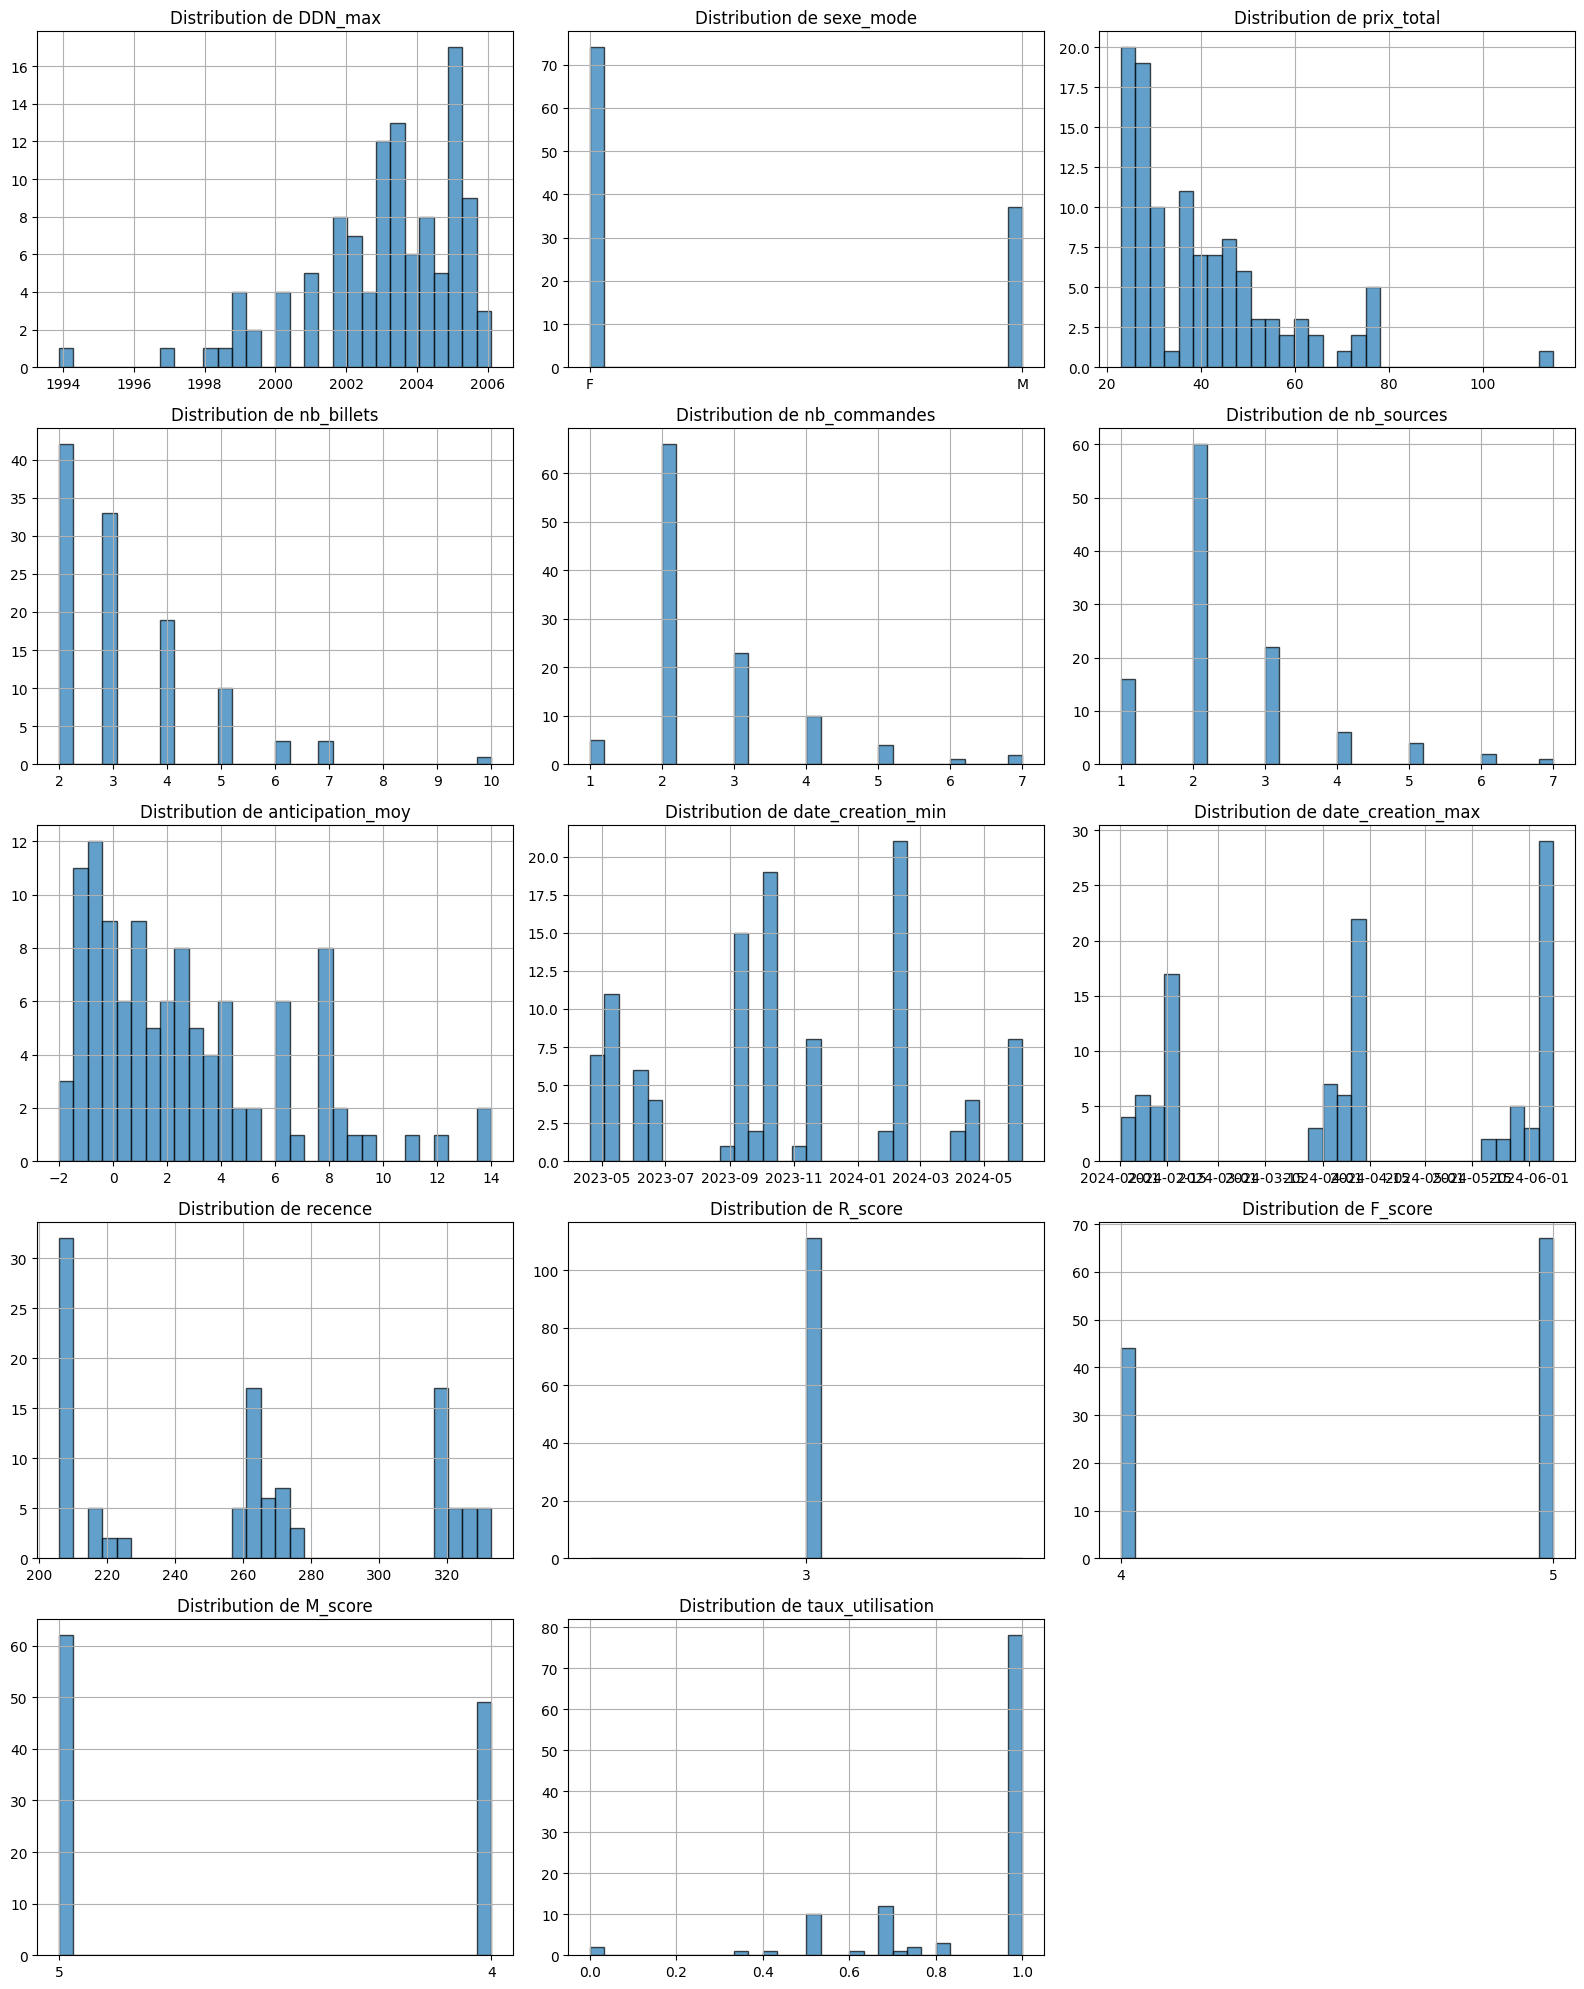

In [ ]:
num_vars = features.copy()
print("Variables numériques : ", num_vars)
n_cols = 3
n_rows = (len(num_vars) + n_cols - 1) // n_cols

# Histogrammes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()
for i, var in enumerate(num_vars):
    df_apprentissage[var].hist(ax=axes[i], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution de {var}')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

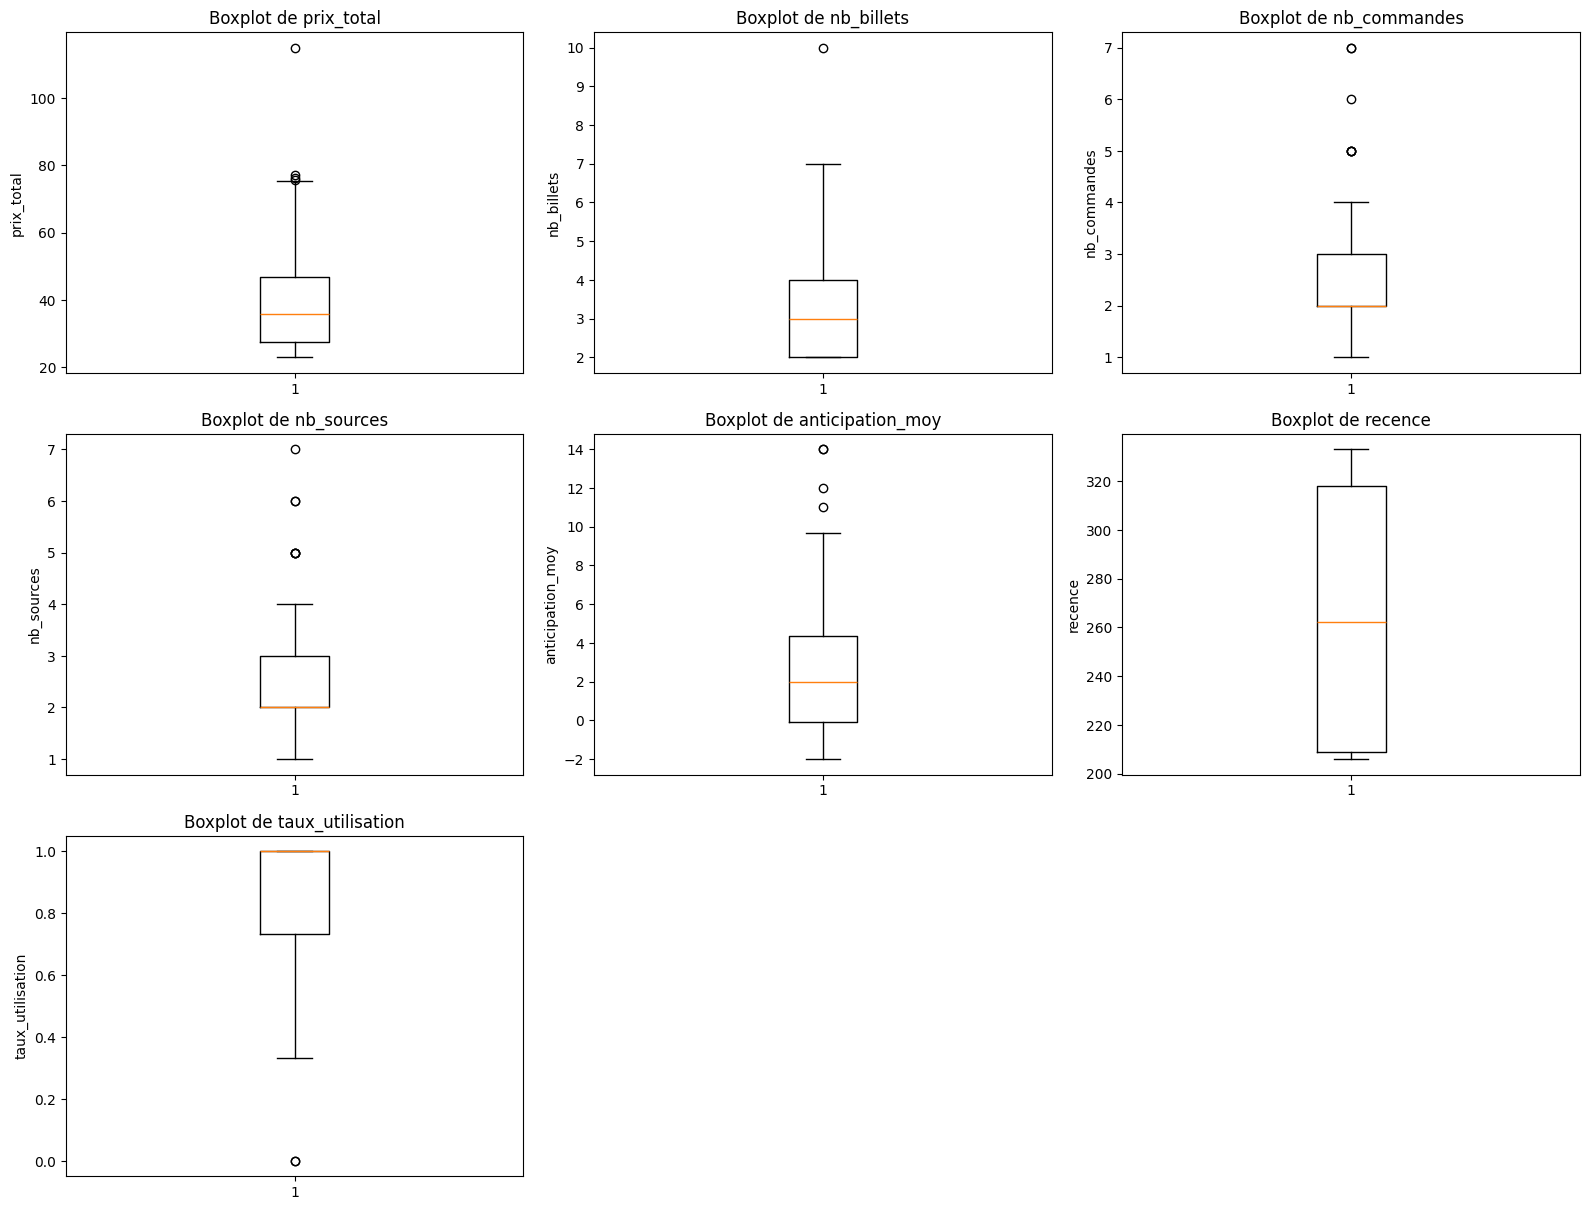

In [ ]:
# Boxplots avec vérification de présence et de type numérique
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*4))
axes = axes.flatten()


for i, var in enumerate(features_numeriques):
    if var in df_apprentissage.columns:
        # Création du boxplot via matplotlib pour éviter les problèmes pandas
        axes[i].boxplot(df_apprentissage[var].dropna())
        axes[i].set_title(f'Boxplot de {var}')
        axes[i].set_ylabel(var)
    else:
        axes[i].text(0.5, 0.5, f'{var} absent', ha='center', va='center')
        axes[i].set_title(f'Variable manquante')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


## 2-Analyse bivariée des variables explicatives et de la variable cible


/tmp/ipykernel_44423/2061201930.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['0', '1'])
/tmp/ipykernel_44423/2061201930.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['0', '1'])
/tmp/ipykernel_44423/2061201930.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_0, data_1], labels=['0', '1'])
/tmp/ipykernel_44423/2061201930.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped i

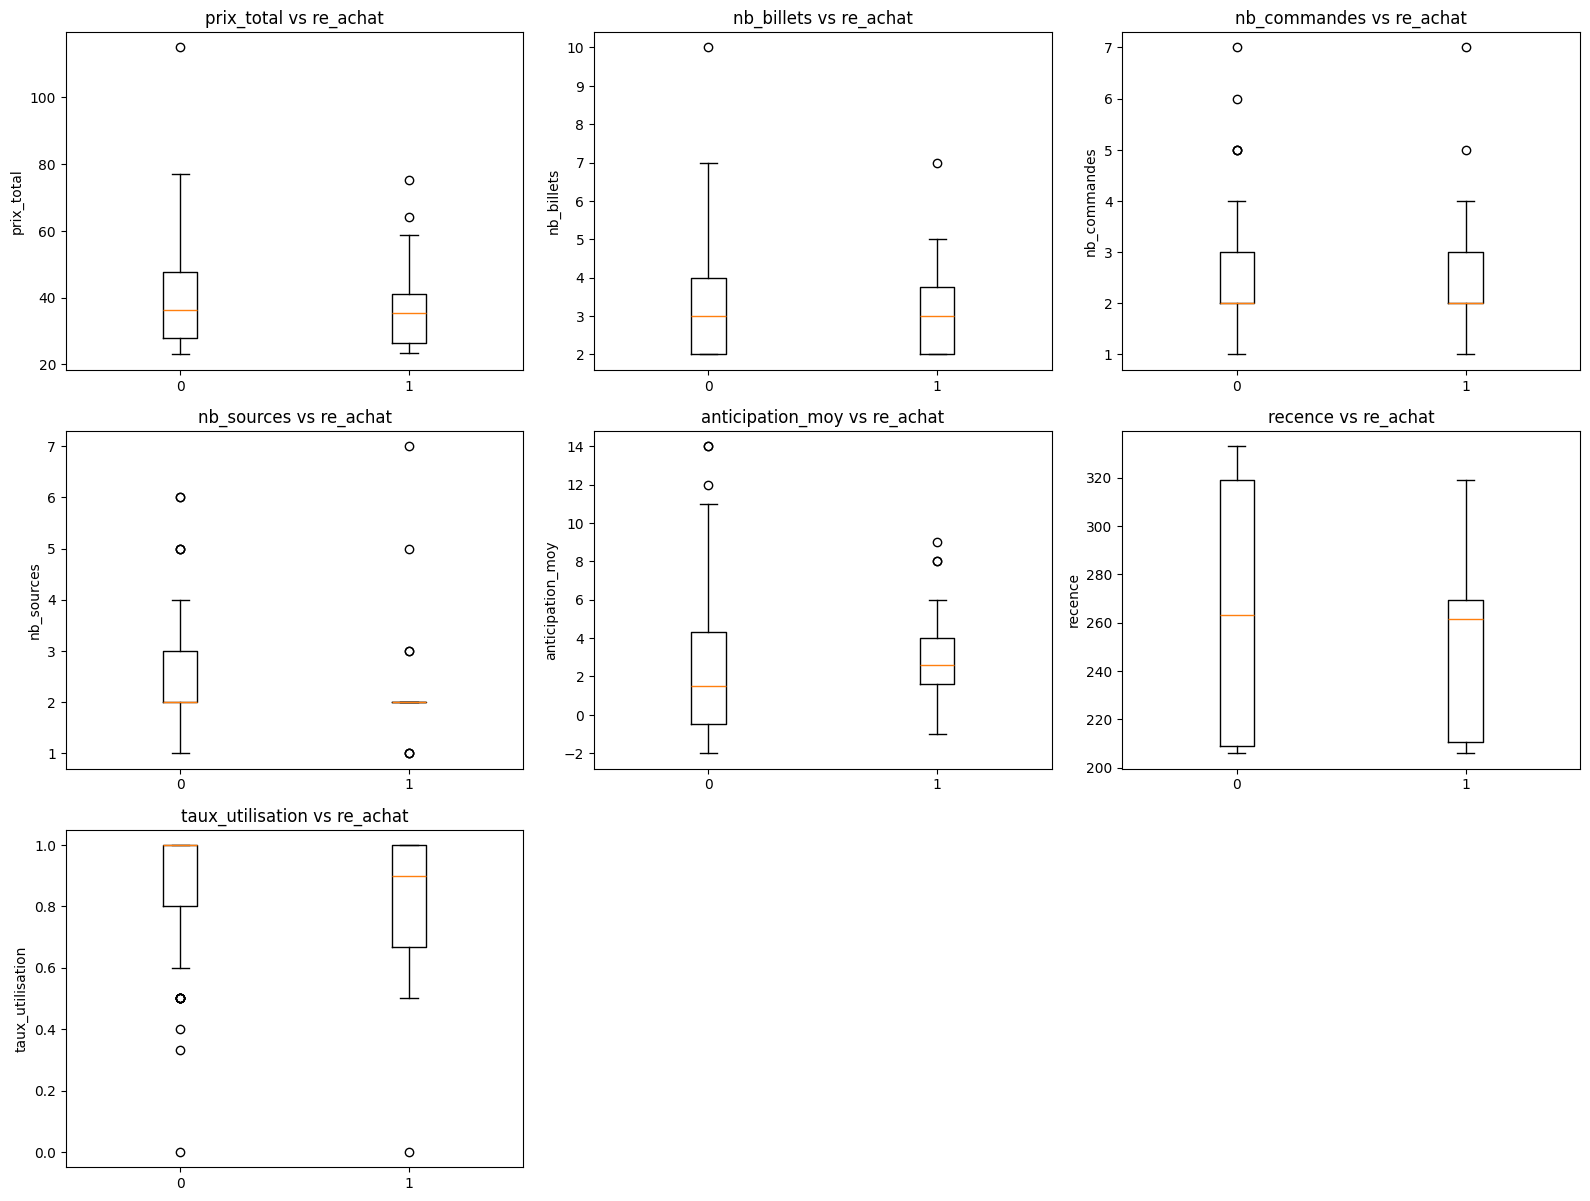

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols , figsize=(16, n_rows*4))
axes = axes.flatten()
for i, var in enumerate(features_numeriques):
        # Boxplots comparatifs pour les deux classes
    data_0 = df_apprentissage[df_apprentissage['re_achat'] == 0][var].dropna()
    data_1 = df_apprentissage[df_apprentissage['re_achat'] == 1][var].dropna()
    bp = axes[i].boxplot([data_0, data_1], labels=['0', '1'])
    axes[i].set_title(f'{var} vs re_achat')
    axes[i].set_ylabel(var)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
# Corrélations avec la cible (point-bisériale)
from scipy.stats import pointbiserialr
correlations = []
for var in features_numeriques:
    corr, pval = pointbiserialr(df_apprentissage['re_achat'], df_apprentissage[var])
    correlations.append((var, corr, pval))

correlations = pd.DataFrame(correlations, columns=['variable', 'correlation', 'p_value'])
print("\nCorrélation point-bisériale avec la cible :")
print(correlations.sort_values('correlation', ascending=False))


Corrélation point-bisériale avec la cible :
           variable  correlation   p_value
4  anticipation_moy     0.073054  0.446076
2      nb_commandes     0.013875  0.885081
3        nb_sources     0.000592  0.995082
1        nb_billets    -0.018326  0.848602
0        prix_total    -0.062895  0.511962
5           recence    -0.135852  0.155116
6  taux_utilisation    -0.162270  0.088837


Les résultats de la correlation entre les variables et la cible peuvent montre que toutes les **variables ont une corrélation relativement faible avec la cible et aucune n'est statistiquement significative comparé au seuil classique**.
Cela suggère que les variables disponibles dans la table d'apprentissage ne sont pas de bons prédicteurs pour identifier les clients qui vont racheter.

Il est possible que d'autres variables, non incluses dans la table, soient nécessaires pour améliorer la performance du modèle de prédiction. En l'état actuel, il semble difficile de construire un modèle de prédiction efficace avec les variables disponibles, et **il serait nécessaire d'explorer d'autres sources de données ou d'autres techniques de modélisation pour mieux comprendre les facteurs qui influencent le comportement d'achat des clients**.

## 3-Entraînement des modèles de classification

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
""" On réutilise la fonction d'évaluation définit dans notre cours de data mining pour les modèles de classification, qui affiche
la matrice de confusion, le score d'accuracy et le rapport de classification pour les données d'entraînement et de test.
Cette fontion permettra d'évaluer les performances de nos modèles de classification sur les données d'entraînement et de test,
en fournissant des métriques clés pour l'analyse des résultats.
"""

def evaluate(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("RESULTATS TRAINING: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"MATRICE DE CONFUSION:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"SCORE ACCURACY:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"RAPPORT CLASSIFICATION:\n{clf_report}")

    print("RESULTS TEST: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"MATRICE DE CONFUSION:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"SCORE ACCURACY:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"RAPPORT CLASSIFICATION:\n{clf_report}")

### 3.1 Modèle 1 : régression logistique simple

In [ ]:
X = df_apprentissage[features_numeriques]
y = df_apprentissage['re_achat']

# On découpe en train/test en stratifiant sur la variable cible pour conserver la même proportion de classes dans les deux ensembles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# Normalisation pour les modèles linéaires
"""
 Il est important de noter que lorsque les données ne sont pas de meme unitées, une stardisation est nécessaire pour que
certaines variables ne dominent pas les autres dans les algorithmes d'apprentissage automatique.
"""
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Modèle 1 : Régression logistique simple
"""On définit un modèle de régression logistique simple pour entrainer notre algorithme de prédiction
"""
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_proba_log = logreg.predict_proba(X_test_scaled)[:, 1]

evaluate(logreg, X_train_scaled, X_test_scaled, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [12  0]]
SCORE ACCURACY:
0.8442
RAPPORT CLASSIFICATION:
                   0     1  accuracy  macro avg  weighted avg
precision   0.844156   0.0  0.844156   0.422078      0.712599
recall      1.000000   0.0  0.844156   0.500000      0.844156
f1-score    0.915493   0.0  0.844156   0.457746      0.772819
support    65.000000  12.0  0.844156  77.000000     77.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[28  0]
 [ 6  0]]
SCORE ACCURACY:
0.8235
RAPPORT CLASSIFICATION:
                   0    1  accuracy  macro avg  weighted avg
precision   0.823529  0.0  0.823529   0.411765      0.678201
recall      1.000000  0.0  0.823529   0.500000      0.823529
f1-score    0.903226  0.0  0.823529   0.451613      0.743833
support    28.000000  6.0  0.823529  34.000000     34.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

Nous constatons notre modèle de régression logistique simple présente **un score supérieure 0.8**. Toute fois, il est important de noter que le **score d'accuracy peut etre trompeur**.

La matrice de confusfion nous montre bien le modèle parvient parvient à identifier correctement les clients qui ne vont pas racheter (classe 0), mais il a du mal à identifier les clients qui vont racheter (classe 1), ce qui se traduit par un nombre élevé de faux négatifs.

Cela suggère que le** modèle est biaisé** vers la classe majoritaire (non-racheteurs) et pourrait bénéficier d'un ajustement des seuils de classification ou de l'utilisation de techniques de rééchantillonnage pour équilibrer les classes.
De plus, le rapport de classification indique une précision et un rappel faibles pour la classe 1, ce qui confirme que le modèle a du mal à prédire correctement les clients qui vont racheter.

En résumé, bien que le score d'accuracy soit élevé, il est crucial d'examiner d'autres métriques pour évaluer la performance du modèle, surtout dans des cas de déséquilibre de classes.

### 3.2 Modèle 2 : modèle logistique avec stepwise

In [ ]:
# Modèle 2 : Régression logistique avec sélection stepwise (RFE)
n_features = min(6, len(features_numeriques))  # Ne pas dépasser le nombre de features
if n_features > 0:
    selector = RFE(logreg, n_features_to_select=n_features, step=1)
    selector.fit(X_train_scaled, y_train)
    selected_features = [features_numeriques[i] for i in range(len(features_numeriques)) if selector.support_[i]]
    print("Variables sélectionnées :", selected_features)

    X_train_stw = selector.transform(X_train_scaled)
    X_test_stw = selector.transform(X_test_scaled)
    logreg_stw = LogisticRegression(random_state=42, max_iter=1000)
    logreg_stw.fit(X_train_stw, y_train)
    y_proba_stw = logreg_stw.predict_proba(X_test_stw)[:, 1]
    evaluate(logreg_stw, X_train_stw, X_test_stw, y_train, y_test)
else:
    print("Pas assez de features pour RFE.")
    logreg_stw = None
    y_proba_stw = None

Variables sélectionnées : ['prix_total', 'nb_billets', 'nb_commandes', 'nb_sources', 'anticipation_moy', 'recence']
RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [12  0]]
SCORE ACCURACY:
0.8442
RAPPORT CLASSIFICATION:
                   0     1  accuracy  macro avg  weighted avg
precision   0.844156   0.0  0.844156   0.422078      0.712599
recall      1.000000   0.0  0.844156   0.500000      0.844156
f1-score    0.915493   0.0  0.844156   0.457746      0.772819
support    65.000000  12.0  0.844156  77.000000     77.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[28  0]
 [ 6  0]]
SCORE ACCURACY:
0.8235
RAPPORT CLASSIFICATION:
                   0    1  accuracy  macro avg  weighted avg
precision   0.823529  0.0  0.823529   0.411765      0.678201
recall      1.000000  0.0  0.823529   0.500000      0.823529
f1-score    0.903226  0.0  0.823529   0.451613      0.743833
support    28.000000  6.0  0.823529  34.000000     34.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packag

Tout comme pour le modèle de régression logistique simple, **le modèle avec sélection stepwise (RFE)** présente également **un score d'accuracy élevé**.

Cependant, il est important de noter que nous retrouvons le même p**roblème de déséquilibre de classes**, avec une matrice de confusion qui montre un nombre élevé de faux négatifs pour la classe 1 (clients qui vont racheter).

Cela suggère que même avec la sélection de features, **le modèle a du mal à identifier correctement les clients qui vont racheter**. Le rapport de classification confirme également une précision et un rappel faibles pour la classe 1, ce qui indique que le modèle n'est pas efficace pour prédire les clients qui vont racheter.

En conclusion, bien que la sélection stepwise puisse aider à réduire le nombre de features, **elle ne résout pas le problème de déséquilibre de classes**, et il serait nécessaire d'explorer d'autres techniques pour améliorer la performance du modèle sur la classe minoritaire.

### 3-3-modèle 3 : k plus proches voisins (KNN)

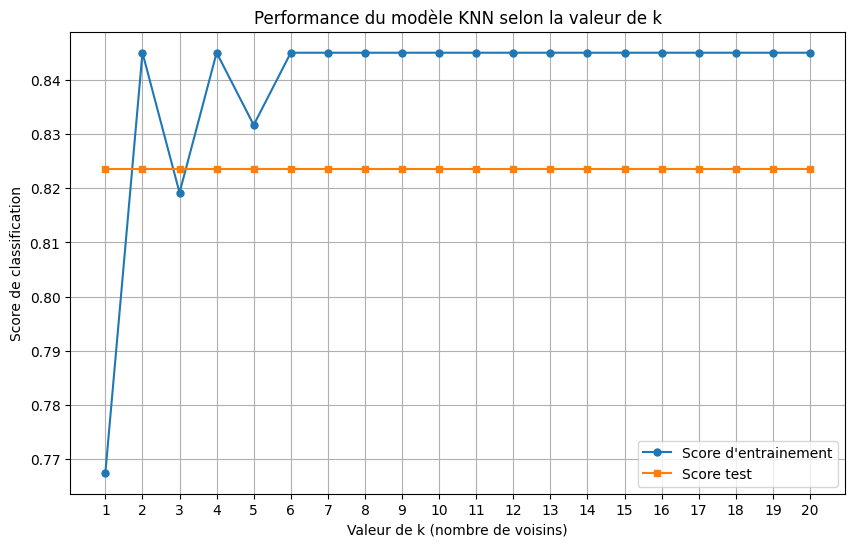

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
## import greadSearchCV pour la recherche d'hyperparamètres
from sklearn.model_selection import GridSearchCV

# Recherche du meilleur hyperparamètre k
from sklearn.neighbors import KNeighborsClassifier
## On définit une plage de valeurs pour k (nombre de voisins) que nous allons tester pour trouver le meilleur modèle KNN en utilisant GridSearchCV pour évaluer
# les performances de chaque valeur de k sur les données d'entraînement et de test.
k_values = range(1, 21)
train_scores = []
test_scores = []

for k in k_values:
    knn = GridSearchCV(KNeighborsClassifier(), param_grid={'n_neighbors': [k]}, cv=5)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.best_score_)
    test_scores.append(knn.score(X_test_scaled, y_test))

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Score d\'entrainement', markersize=5)
plt.plot(k_values, test_scores, 's-', label='Score test', markersize=5)
plt.xlabel('Valeur de k (nombre de voisins)')
plt.ylabel('Score de classification')
plt.title('Performance du modèle KNN selon la valeur de k')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

In [ ]:
# Meilleur k
best_k = k_values[np.argmax(test_scores)]
print(f"Meilleure valeur de k : {best_k} (accuracy test = {max(test_scores):.4f})")

# Entraînement du meilleur modèle
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

# Évaluation
print("\nÉvaluation du modèle KNN:")
knn_scores = evaluate(best_knn, X_train_scaled, X_test_scaled, y_train, y_test)

Meilleure valeur de k : 1 (accuracy test = 0.8235)

Évaluation du modèle KNN:
RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [ 0 12]]
SCORE ACCURACY:
1.0000
RAPPORT CLASSIFICATION:
              0     1  accuracy  macro avg  weighted avg
precision   1.0   1.0       1.0        1.0           1.0
recall      1.0   1.0       1.0        1.0           1.0
f1-score    1.0   1.0       1.0        1.0           1.0
support    65.0  12.0       1.0       77.0          77.0
RESULTS TEST: 
MATRICE DE CONFUSION:
[[27  1]
 [ 5  1]]
SCORE ACCURACY:
0.8235
RAPPORT CLASSIFICATION:
                   0         1  accuracy  macro avg  weighted avg
precision   0.843750  0.500000  0.823529   0.671875      0.783088
recall      0.964286  0.166667  0.823529   0.565476      0.823529
f1-score    0.900000  0.250000  0.823529   0.575000      0.785294
support    28.000000  6.000000  0.823529  34.000000     34.000000


Contrairement à la régression logistique, **nous remarquons que le modèle KNN parvient à identifier de façon parfaite les deux classes du modèle(les clients qui vont racheter et ceux qui ne vont pas racheter)** pour les données d'entrainement. Mais pour les données de test, les perfoemances du modèle KNN semblent limités car il y a un nombre élevé de faux négatifs pour la classe 1 (clients qui vont racheter), ce qui suggère que le modèle a du mal à identifier correctement les clients qui vont racheter.
Cependant, il est important de noter que le modèle KNN peut être sensible au bruit dans les données et peut ne pas généraliser aussi bien que d'autres modèles plus complexes, surtout dans notre cas ou les classes ne sont pas équilibrées.

### 3.4 Modèle 4 : Random Forest

In [ ]:
### Prédiction avec random forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

evaluate(rf, X_train_scaled, X_test_scaled, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [ 0 12]]
SCORE ACCURACY:
1.0000
RAPPORT CLASSIFICATION:
              0     1  accuracy  macro avg  weighted avg
precision   1.0   1.0       1.0        1.0           1.0
recall      1.0   1.0       1.0        1.0           1.0
f1-score    1.0   1.0       1.0        1.0           1.0
support    65.0  12.0       1.0       77.0          77.0
RESULTS TEST: 
MATRICE DE CONFUSION:
[[26  2]
 [ 6  0]]
SCORE ACCURACY:
0.7647
RAPPORT CLASSIFICATION:
                   0    1  accuracy  macro avg  weighted avg
precision   0.812500  0.0  0.764706   0.406250      0.669118
recall      0.928571  0.0  0.764706   0.464286      0.764706
f1-score    0.866667  0.0  0.764706   0.433333      0.713725
support    28.000000  6.0  0.764706  34.000000     34.000000


Tout comme le modèle KNN, le modèle de Random Forest parvient à identifier parfaitement **les deux classes du modèle**, avec une matrice de confusion parfaite et un rapport de classification indiquant une précision et un rappel parfaits pour les deux classes sur les données d'entrainement.
Cependant, pour les données de test, le modèle de Random Forest montre des performances limitées, avec un nombre élevé de faux négatifs pour la classe 1 (clients qui vont racheter). Cela suggère que le modèle a du mal à identifier correctement les clients qui vont racheter sur les données de test, ce qui peut être dû à un surapprentissage sur les données d'entrainement.

### 3.5 Modèle 5 : Decision Tree

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': range(2, 10),
    'min_samples_split': range(2, 10)
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid,
                       cv=5)

grid_dt.fit(X_train_scaled, y_train)

print("Meilleurs paramètres :", grid_dt.best_params_)
print("Score validation :", grid_dt.best_score_)

Meilleurs paramètres : {'max_depth': 2, 'min_samples_split': 2}
Score validation : 0.8708333333333333


In [ ]:
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test_scaled)
y_proba_dt = best_dt.predict_proba(X_test_scaled)[:, 1]
evaluate(best_dt, X_train_scaled, X_test_scaled, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[65  0]
 [10  2]]
SCORE ACCURACY:
0.8701
RAPPORT CLASSIFICATION:
                   0          1  accuracy  macro avg  weighted avg
precision   0.866667   1.000000   0.87013   0.933333      0.887446
recall      1.000000   0.166667   0.87013   0.583333      0.870130
f1-score    0.928571   0.285714   0.87013   0.607143      0.828386
support    65.000000  12.000000   0.87013  77.000000     77.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[25  3]
 [ 6  0]]
SCORE ACCURACY:
0.7353
RAPPORT CLASSIFICATION:
                   0    1  accuracy  macro avg  weighted avg
precision   0.806452  0.0  0.735294   0.403226      0.664137
recall      0.892857  0.0  0.735294   0.446429      0.735294
f1-score    0.847458  0.0  0.735294   0.423729      0.697906
support    28.000000  6.0  0.735294  34.000000     34.000000


Le **score de validation** croisée obtenu est de **0.87**, ce qui indique que le modèle semble performant sur les données d’entraînement.

Cependant, l’évaluation sur l’échantillon test montre des performances plus limitées. La matrice de confusion montre que le modèle prédit correctement **25 clients** qui ne vont pas racheter **(classe 0)** et se trompe pour 3 d’entre eux, tandis qu’il ne **parvient pas à identifier les clients qui vont racheter (classe 1)**, avec 6 faux négatifs et aucun vrai positif.


Le modèle identifie correctement la majorité des **clients qui ne rachètent pas (classe 0)** avec un recall de 0.89. En revanche, il **n’identifie aucun client qui va racheter (classe 1)**, ce qui se traduit par un **recall et une précision de 0 pour cette classe**.

L’**accuracy globale est de 0.74**, mais cette métrique peut être **trompeuse** en raison du **déséquilibre entre les classes**. En effet, la majorité des observations appartient à la classe 0, ce qui pousse le modèle à privilégier cette classe.

En conclusion, bien que l’arbre de décision obtienne un score correct en validation croisée, **il échoue à détecter les clients susceptibles de racheter**, ce qui limite fortement son intérêt dans le cadre d’une **campagne de relance client**.

Pour ce type de problème, il est préférable d’utiliser des modèles capables de mieux détecter la **classe minoritaire**, comme **KNN** ou **Random Forest**, qui ont montré de meilleures performances dans notre analyse.

## 4-Évaluation et comparaison des modèles

Les différents modèles ont été évalués à l’aide de plusieurs métriques : l’accuracy, la matrice de confusion ainsi que le rapport de classification (précision et rappel).

Les **deux modèles de régression logistique** (simple et avec sélection de variables Stepwise) présentent une **accuracy élevée (supérieure à 0,8)**. Cependant, cette métrique est trompeuse dans notre cas car les données sont déséquilibrées. La matrice de confusion montre que ces modèles identifient correctement les clients qui ne vont pas racheter (classe 0), mais qu’ils ont des difficultés à détecter les clients qui vont racheter (classe 1).
Cela se traduit par un **nombre important de faux négatifs**, ce qui signifie que certains clients susceptibles de racheter ne seraient pas ciblés par la campagne.

Le modèle **Decision Tree** présente également** des performances limitées**. Bien que le modèle obtienne un score de validation correct, la matrice de confusion montre qu’il ne parvient pas à identifier les clients qui vont racheter (classe 1). Le modèle prédit principalement la classe majoritaire (clients qui ne rachètent pas), ce qui limite son utilité dans le cadre d’une campagne de relance client.

À l’inverse, **les modèles KNN et Random Forest** présentent des performances un peu acceptable. Les matrices de confusion indiquent **aucune erreur de classification** sur les données d'entrainement. Ces modèles présentent des performances plus efficaces pour identifier les deux classes.

Dans le contexte de cette campagne marketing, **le rappel (recall) sur la classe 1 est la métrique la plus pertinente à optimiser**. En effet, l’objectif est d’identifier un maximum de clients susceptibles de racheter afin de maximiser l’efficacité de la campagne. Un faux négatif signifie qu’un client potentiellement réactivable ne sera pas contacté, ce qui représente une perte d’opportunité de gain.

Ainsi, il est préférable de privilégier un modèle capable **de détecter un maximum de clients réactivables,** même si cela entraîne légèrement plus de faux positifs.

## 5. Analyse des courbes de profit des modèles


In [ ]:
cout_relance = 4
gain_reactivation = 30

In [ ]:
def profit_curve(y_true, y_scores, cost, gain):
    """Calcule le profit pour différents seuils de décision."""
    order = np.argsort(y_scores)[::-1] # Tri par ordre décroissant des scores de probabilité
    y_true_sorted = y_true[order]
    nb_contactes = np.arange(1, len(y_true_sorted)+1)
    nb_reactives = np.cumsum(y_true_sorted) ## Cumul des clients réactivés
    profit = nb_reactives * gain - nb_contactes * cost
    return profit, nb_contactes, nb_reactives

profit_log, nb_contact_log, _ = profit_curve(y_test.values, y_proba_log, cout_relance, gain_reactivation)

if y_proba_stw is not None:
    profit_stw, nb_contact_stw, _ = profit_curve(y_test.values, y_proba_stw, cout_relance, gain_reactivation)
else:
    profit_rf, nb_contact_rf = None, None

profit_knn, nb_contact_knn, _ = profit_curve(y_test.values, y_proba_knn, cout_relance, gain_reactivation)
profit_rf , nb_contact_rf, _ = profit_curve(y_test.values, y_proba_rf, cout_relance, gain_reactivation)
profit_dt , nb_contact_dt, _ = profit_curve(y_test.values, y_proba_dt, cout_relance, gain_reactivation)


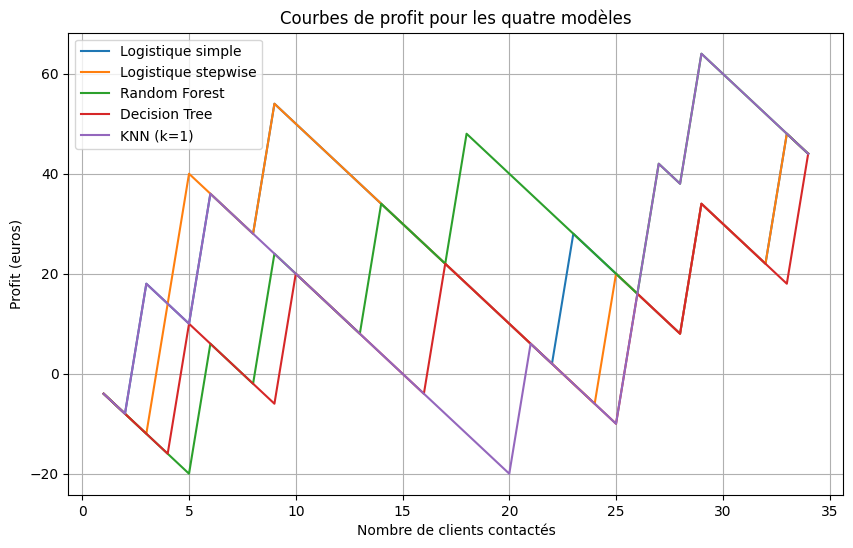

In [ ]:
# Tracé des courbes de profit
plt.figure(figsize=(10,6))
plt.plot(nb_contact_log, profit_log, label='Logistique simple')
if profit_stw is not None:
    plt.plot(nb_contact_stw, profit_stw, label='Logistique stepwise')
if profit_rf is not None:
    plt.plot(nb_contact_rf, profit_rf, label='Random Forest')
if profit_dt is not None:
    plt.plot(nb_contact_dt, profit_dt, label='Decision Tree')
plt.plot(nb_contact_knn, profit_knn, label='KNN (k=1)')
plt.xlabel('Nombre de clients contactés')
plt.ylabel('Profit (euros)')
plt.title('Courbes de profit pour les quatre modèles')
plt.legend()
plt.grid(True)
plt.show()

## 6-Détermination du gain maximal et de la stratégie de campagne

In [ ]:
# Calcul du profit maximal et du nombre de clients à contacter pour chaque modèle
max_profit_log = profit_log.max()
idx_max_log = profit_log.argmax()
print(f"Modèle logistique simple : profit max = {max_profit_log:.2f} euros, en contactant {nb_contact_log[idx_max_log]} clients")

max_profit_stw = profit_stw.max()
idx_max_stw = profit_stw.argmax()
print(f"Modèle logistique stepwise : profit max = {max_profit_stw:.2f} euros, en contactant {nb_contact_stw[idx_max_stw]} clients")

max_profit_knn = profit_knn.max()
idx_max_knn = profit_knn.argmax()
print(f"Modèle KNN : profit max = {max_profit_knn:.2f} euros, en contactant {nb_contact_knn[idx_max_knn]} clients")

max_profit_dt = profit_dt.max()
idx_max_dt = profit_dt.argmax()
print(f"Modèle Decision Tree : profit max = {max_profit_dt:.2f} euros, en contactant {nb_contact_dt[idx_max_dt]} clients")

max_profit_rf = profit_rf.max() if profit_rf is not None else -np.inf
idx_max_rf = profit_rf.argmax()
print(f"Modèle Random Forest : profit max = {max_profit_rf:.2f} euros, en contactant {nb_contact_rf[idx_max_rf]} clients")

# Comparaison
profits = [max_profit_log, max_profit_stw, max_profit_knn, max_profit_rf, max_profit_dt]
best_idx = np.argmax(profits)
best_names = ['Logistique simple', 'Logistique stepwise', 'KNN', 'Random Forest']
print(f"\nLe meilleur modèle est {best_names[best_idx]} avec un gain maximal de {profits[best_idx]:.2f} euros.")
print(f"Cela représente {nb_contact_log[idx_max_log]/len(y_test)*100:.1f}% des clients de l'échantillon test (à adapter selon le meilleur modèle).")

Modèle logistique simple : profit max = 54.00 euros, en contactant 9 clients
Modèle logistique stepwise : profit max = 54.00 euros, en contactant 9 clients
Modèle KNN : profit max = 64.00 euros, en contactant 29 clients
Modèle Decision Tree : profit max = 44.00 euros, en contactant 34 clients
Modèle Random Forest : profit max = 64.00 euros, en contactant 29 clients

Le meilleur modèle est KNN avec un gain maximal de 64.00 euros.
Cela représente 26.5% des clients de l'échantillon test (à adapter selon le meilleur modèle).


L’analyse des courbes de profit permet d’identifier le gain maximal que peut générer la campagne ainsi que la proportion optimale de clients à contacter.

Les résultats obtenus sont les suivants :


*  **Modèle logistique simple** : profit maximal de **54 €** en contactant **9 clients**
*  **Modèle logistique stepwise**: profit maximal de **54 €** en contactant **9 clients**
*  **Modèle KNN** : profit maximal de **64 €** en contactant **29 clients**
*  **Modèle Random Forest** : profit maximal de **64 €** en contactant **29 clients**
*  **Modèle Decision Tree** : profit maximal de **44 €** en contactant **34 clients**

Les modèles **KNN**et **Random Forest** permettent d’obtenir **le gain maximal le plus élevé,** avec un **profit de 64 €**.

Le modèle **Decision Tree**, quant à lui, obtient un profit maximal plus faible (44 €) et nécessite de contacter davantage de clients (34 clients), ce qui le rend moins efficace dans l’optimisation de la campagne.

Le meilleur modèle retenu est **KNN**, qui permet d’atteindre ce gain en contactant **29 clients**, soit environ **26,5 % des clients de l’échantillon test**.

Ainsi, pour optimiser la rentabilité de la campagne de relance, il serait recommandé de c**ibler uniquement les 26,5 % de clients ayant la probabilité la plus élevée de rachat selon le modèle KNN**. Cette stratégie permet de maximiser le profit tout en limitant les coûts de contact inutiles.